In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from tensorflow.keras.applications import ResNet50, MobileNetV2
from sklearn.preprocessing import StandardScaler

2025-07-11 20:29:29.153651: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752244169.357244    8969 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752244169.411171    8969 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752244169.822234    8969 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752244169.822295    8969 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752244169.822304    8969 computation_placer.cc:177] computation placer alr

# Problem - 1 : Training an autoencoder as a 2D feature generator and displaying CIFAR10 dataset's features

W0000 00:00:1752243847.749033    6986 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2025-07-11 20:24:08.108433: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


Epoch 1/30


2025-07-11 20:24:08.693702: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 0.0520
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.0375
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.0369
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 0.0367
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0362
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0357
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0355
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0354
Epoch 9/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.0353
Epoch 10/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.0353
Epoch 11/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0352
Epoch 12/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0348
Epoch 13/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 34ms/step - loss: 0.0350
Epoch 14/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - loss: 0.0349
Epoch 15/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step 

2025-07-11 20:27:38.185451: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


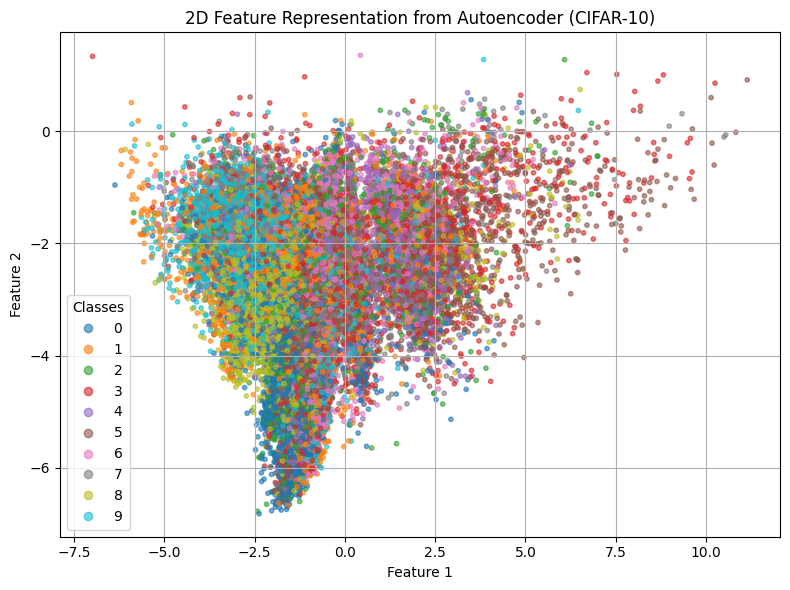

In [3]:
(x_train, y_train), (_, _) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
y_train = y_train.flatten()

def build_autoencoder():
    inputs = layers.Input(shape=(32, 32, 3))
    x = layers.Flatten()(inputs)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    bottleneck = layers.Dense(2, name='bottleneck')(x)

    x = layers.Dense(128, activation='relu')(bottleneck)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(32*32*3, activation='sigmoid')(x)
    outputs = layers.Reshape((32, 32, 3))(x)

    autoencoder = models.Model(inputs, outputs)
    encoder = models.Model(inputs, bottleneck)
    return autoencoder, encoder

autoencoder, encoder = build_autoencoder()
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(x_train, x_train, epochs=30, batch_size=256, shuffle=True, verbose=1)

features_2d = encoder.predict(x_train, batch_size=256)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(features_2d[:, 0], features_2d[:, 1], c=y_train, cmap='tab10', s=10, alpha=0.6)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("2D Feature Representation from Autoencoder (CIFAR-10)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.tight_layout()
plt.show()


# Problem - 2 : Comparing autoencoder generated features with features extracted by a pre-trained CNN and reduced by dimension reduction techniques like PCA, t-SNE.

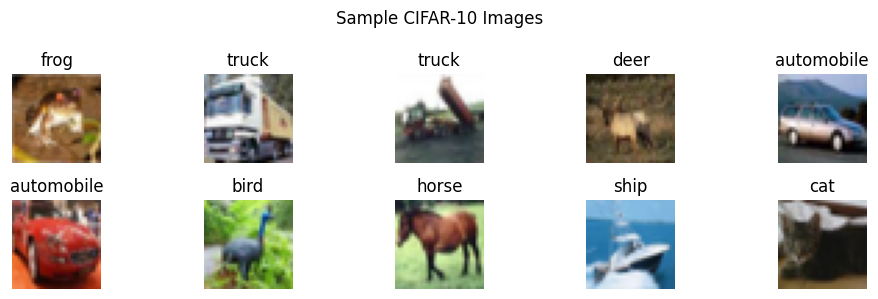

W0000 00:00:1752244190.277300    8969 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/10
40/40 - 3s - 63ms/step - loss: 0.0571
Epoch 2/10
40/40 - 1s - 37ms/step - loss: 0.0458
Epoch 3/10
40/40 - 1s - 37ms/step - loss: 0.0436
Epoch 4/10
40/40 - 1s - 37ms/step - loss: 0.0410
Epoch 5/10
40/40 - 1s - 37ms/step - loss: 0.0387
Epoch 6/10
40/40 - 1s - 37ms/step - loss: 0.0376
Epoch 7/10
40/40 - 2s - 38ms/step - loss: 0.0372
Epoch 8/10
40/40 - 2s - 39ms/step - loss: 0.0372
Epoch 9/10
40/40 - 1s - 37ms/step - loss: 0.0371
Epoch 10/10
40/40 - 1s - 37ms/step - loss: 0.0371
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


2025-07-11 20:38:48.056816: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


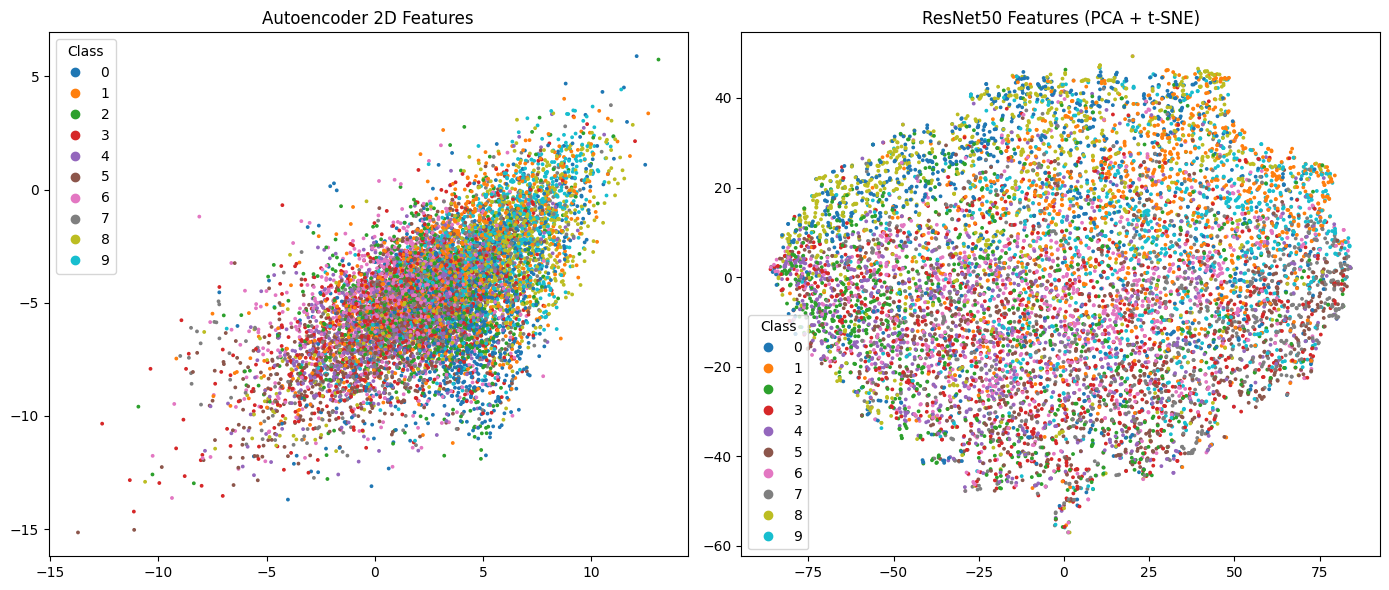

In [ ]:
(x_train, y_train), (_, _) = cifar10.load_data()

x_train = x_train[:10000]
y_train = y_train[:10000]

x_train = x_train.astype('float32') / 255.0
y_train = y_train.flatten()


class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

def build_autoencoder():
    inputs = layers.Input(shape=(32, 32, 3))
    x = layers.Flatten()(inputs)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    z = layers.Dense(2)(x)  # bottleneck 2D feature
    x = layers.Dense(128, activation='relu')(z)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(32 * 32 * 3, activation='sigmoid')(x)
    outputs = layers.Reshape((32, 32, 3))(x)
    return tf.keras.Model(inputs, outputs), tf.keras.Model(inputs, z)

autoencoder, encoder = build_autoencoder()
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(x_train, x_train, epochs=10, batch_size=256, verbose=2)

z_auto = encoder.predict(x_train, batch_size=256)

batch_size = 64

def resize_image(image):
    image = tf.image.resize(image, [224, 224])
    return image

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.map(resize_image).batch(batch_size).prefetch(tf.data.AUTOTUNE)

resnet_model = ResNet50(include_top=False, weights='imagenet', pooling='avg', input_shape=(224, 224, 3))
resnet_model.trainable = False

features_list = []
for batch in dataset:
    features = resnet_model(batch)
    features_list.append(features.numpy())

features_resnet = np.vstack(features_list)

pca = PCA(n_components=50)
resnet_pca = pca.fit_transform(features_resnet)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
resnet_tsne = tsne.fit_transform(resnet_pca)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axs[0].scatter(z_auto[:, 0], z_auto[:, 1], c=y_train, cmap='tab10', s=3)
axs[0].set_title("Autoencoder 2D Features")
axs[0].legend(*scatter1.legend_elements(), title="Class", loc="best")

scatter2 = axs[1].scatter(resnet_tsne[:, 0], resnet_tsne[:, 1], c=y_train, cmap='tab10', s=3)
axs[1].set_title("ResNet50 Features (PCA + t-SNE)")
axs[1].legend(*scatter2.legend_elements(), title="Class", loc="best")

plt.tight_layout()
plt.show()


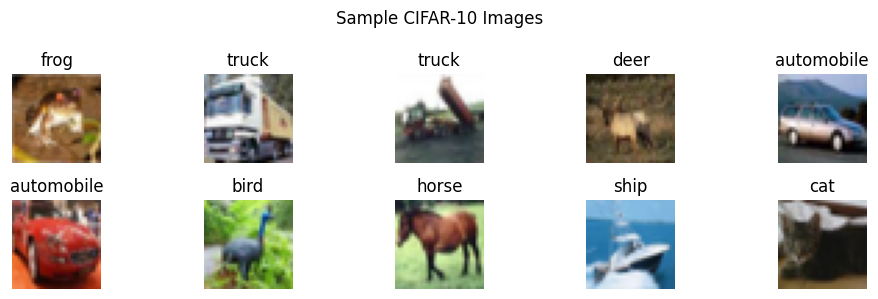

Epoch 1/20
40/40 - 7s - 164ms/step - loss: 0.0565
Epoch 2/20
40/40 - 1s - 37ms/step - loss: 0.0456
Epoch 3/20
40/40 - 2s - 39ms/step - loss: 0.0437
Epoch 4/20
40/40 - 1s - 37ms/step - loss: 0.0415
Epoch 5/20
40/40 - 2s - 38ms/step - loss: 0.0388
Epoch 6/20
40/40 - 2s - 38ms/step - loss: 0.0383
Epoch 7/20
40/40 - 1s - 37ms/step - loss: 0.0372
Epoch 8/20
40/40 - 1s - 37ms/step - loss: 0.0371
Epoch 9/20
40/40 - 1s - 37ms/step - loss: 0.0371
Epoch 10/20
40/40 - 1s - 37ms/step - loss: 0.0371
Epoch 11/20
40/40 - 1s - 35ms/step - loss: 0.0370
Epoch 12/20
40/40 - 2s - 38ms/step - loss: 0.0370
Epoch 13/20
40/40 - 1s - 37ms/step - loss: 0.0369
Epoch 14/20
40/40 - 1s - 37ms/step - loss: 0.0369
Epoch 15/20
40/40 - 1s - 37ms/step - loss: 0.0369
Epoch 16/20
40/40 - 1s - 37ms/step - loss: 0.0368
Epoch 17/20
40/40 - 1s - 37ms/step - loss: 0.0367
Epoch 18/20
40/40 - 1s - 37ms/step - loss: 0.0366
Epoch 19/20
40/40 - 1s - 37ms/step - loss: 0.0366
Epoch 20/20
40/40 - 1s - 35ms/step - loss: 0.0365
40/40 ━━

2025-07-11 20:41:41.432680: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


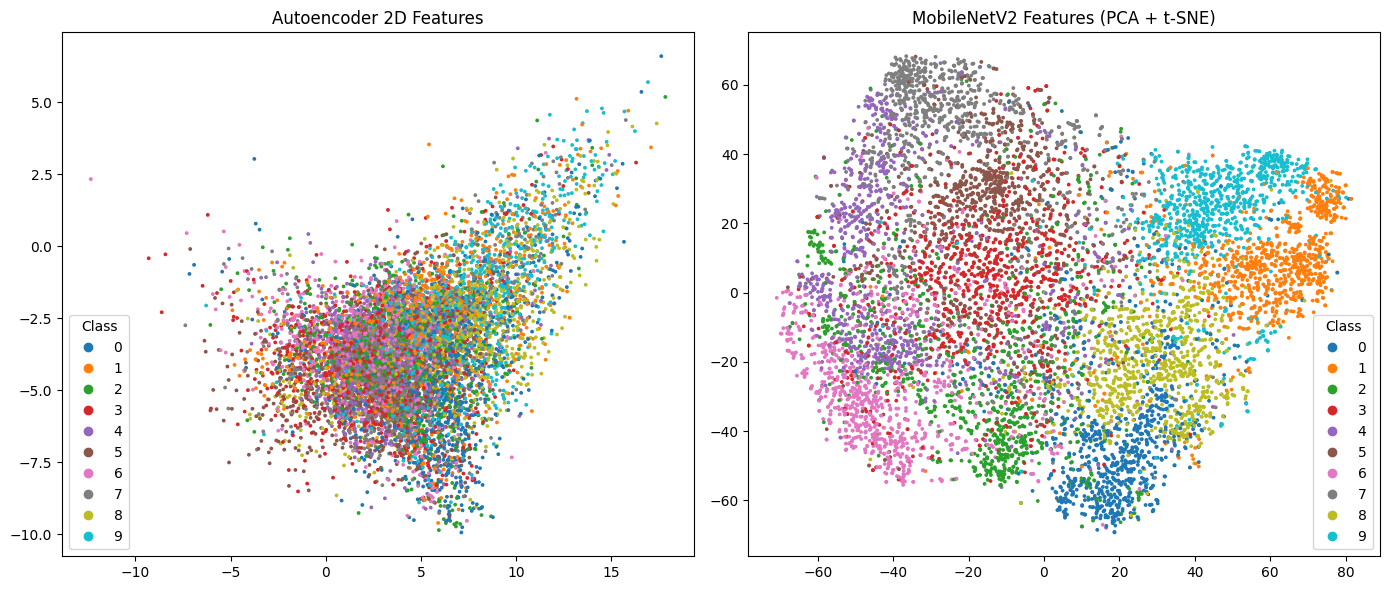

In [ ]:
(x_train, y_train), (_, _) = cifar10.load_data()
x_train = x_train[:10000].astype('float32') / 255.0
y_train = y_train[:10000].flatten()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

def build_autoencoder():
    inputs = layers.Input(shape=(32, 32, 3))
    x = layers.Flatten()(inputs)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    z = layers.Dense(2)(x)
    x = layers.Dense(128, activation='relu')(z)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(32 * 32 * 3, activation='sigmoid')(x)
    outputs = layers.Reshape((32, 32, 3))(x)
    return tf.keras.Model(inputs, outputs), tf.keras.Model(inputs, z)

autoencoder, encoder = build_autoencoder()
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.fit(x_train, x_train, epochs=20, batch_size=256, verbose=2)

z_auto = encoder.predict(x_train, batch_size=256)

def resize_for_mobilenet(image):
    return tf.image.resize(image, [160, 160])

batch_size = 64
dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.map(resize_for_mobilenet).batch(batch_size).prefetch(tf.data.AUTOTUNE)

mobilenet_model = MobileNetV2(include_top=False, weights='imagenet', pooling='avg', input_shape=(160, 160, 3))
mobilenet_model.trainable = False

mobilenet_features = []
for batch in dataset:
    features = mobilenet_model(batch)
    mobilenet_features.append(features.numpy())
features_mobilenet = np.vstack(mobilenet_features)

pca = PCA(n_components=50)
mobilenet_pca = pca.fit_transform(features_mobilenet)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
mobilenet_tsne = tsne.fit_transform(mobilenet_pca)

fig, axs = plt.subplots(1, 2, figsize=(14, 6))

scatter1 = axs[0].scatter(z_auto[:, 0], z_auto[:, 1], c=y_train, cmap='tab10', s=3)
axs[0].set_title("Autoencoder 2D Features")
axs[0].legend(*scatter1.legend_elements(), title="Class", loc="best")

scatter2 = axs[1].scatter(mobilenet_tsne[:, 0], mobilenet_tsne[:, 1], c=y_train, cmap='tab10', s=3)
axs[1].set_title("MobileNetV2 Features (PCA + t-SNE)")
axs[1].legend(*scatter2.legend_elements(), title="Class", loc="best")

plt.tight_layout()
plt.show()


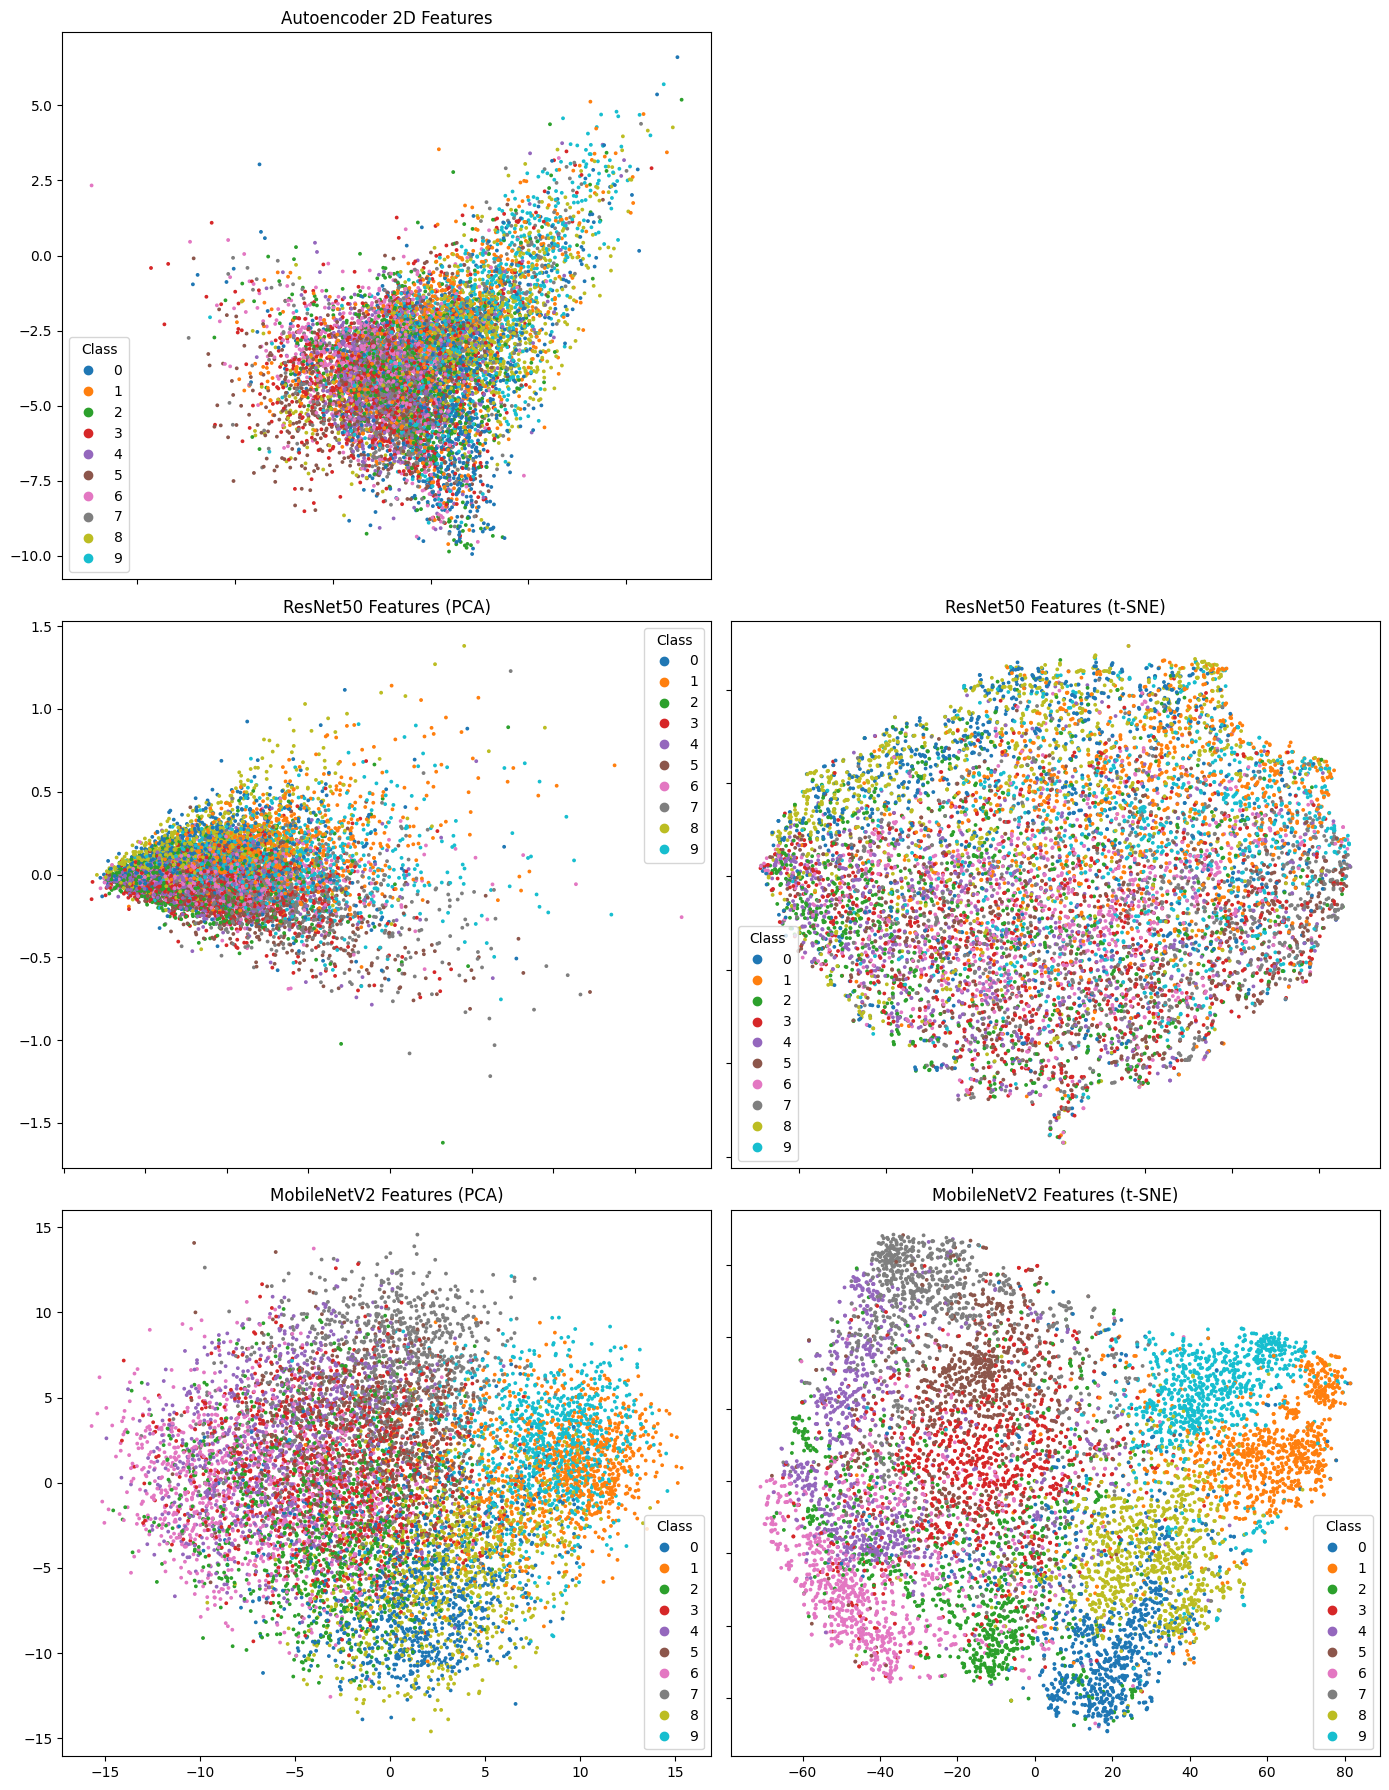

In [ ]:
fig, axs = plt.subplots(3, 2, figsize=(14, 18))

scatter0 = axs[0, 0].scatter(z_auto[:, 0], z_auto[:, 1], c=y_train, cmap='tab10', s=3)
axs[0, 0].set_title("Autoencoder 2D Features")
axs[0, 0].legend(*scatter0.legend_elements(), title="Class", loc="best")

axs[0, 1].axis('off')  

scatter1 = axs[1, 0].scatter(resnet_pca[:, 0], resnet_pca[:, 1], c=y_train, cmap='tab10', s=3)
axs[1, 0].set_title("ResNet50 Features (PCA)")
axs[1, 0].legend(*scatter1.legend_elements(), title="Class", loc="best")

scatter2 = axs[1, 1].scatter(resnet_tsne[:, 0], resnet_tsne[:, 1], c=y_train, cmap='tab10', s=3)
axs[1, 1].set_title("ResNet50 Features (t-SNE)")
axs[1, 1].legend(*scatter2.legend_elements(), title="Class", loc="best")

scatter3 = axs[2, 0].scatter(mobilenet_pca[:, 0], mobilenet_pca[:, 1], c=y_train, cmap='tab10', s=3)
axs[2, 0].set_title("MobileNetV2 Features (PCA)")
axs[2, 0].legend(*scatter3.legend_elements(), title="Class", loc="best")

scatter4 = axs[2, 1].scatter(mobilenet_tsne[:, 0], mobilenet_tsne[:, 1], c=y_train, cmap='tab10', s=3)
axs[2, 1].set_title("MobileNetV2 Features (t-SNE)")
axs[2, 1].legend(*scatter4.legend_elements(), title="Class", loc="best")

for ax in axs.flat:
    ax.label_outer()
plt.tight_layout()
plt.show()


# Problem - 3 : Training a denoising autoencoder for CIFAR10 dataset

2025-07-11 18:47:37.316299: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752238057.513558   19933 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752238057.575987   19933 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752238057.983410   19933 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752238057.983447   19933 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1752238057.983450   19933 computation_placer.cc:177] computation placer alr

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,507 (115.26 KB)

 Trainable params: 29,507 (115.26 KB)

 Non-trainable params: 0 (0.00 B)

2025-07-11 18:47:55.322350: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


Epoch 1/20


2025-07-11 18:47:56.633798: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 614400000 exceeds 10% of free system memory.


391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 109ms/step - loss: 0.0219 - val_loss: 0.0084
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 107ms/step - loss: 0.0081 - val_loss: 0.0073
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - loss: 0.0073 - val_loss: 0.0070
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 42s 108ms/step - loss: 0.0068 - val_loss: 0.0066
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - loss: 0.0066 - val_loss: 0.0065
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - loss: 0.0063 - val_loss: 0.0063
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - loss: 0.0062 - val_loss: 0.0060
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - loss: 0.0061 - val_loss: 0.0060
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - loss: 0.0059 - val_loss: 0.0058
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - loss: 0.0058 - val_loss: 0.0057
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 110ms/step - loss: 0.0058 - val_loss: 0.0056
Epoch 12/20
391/391 ━━━━━━━━━━

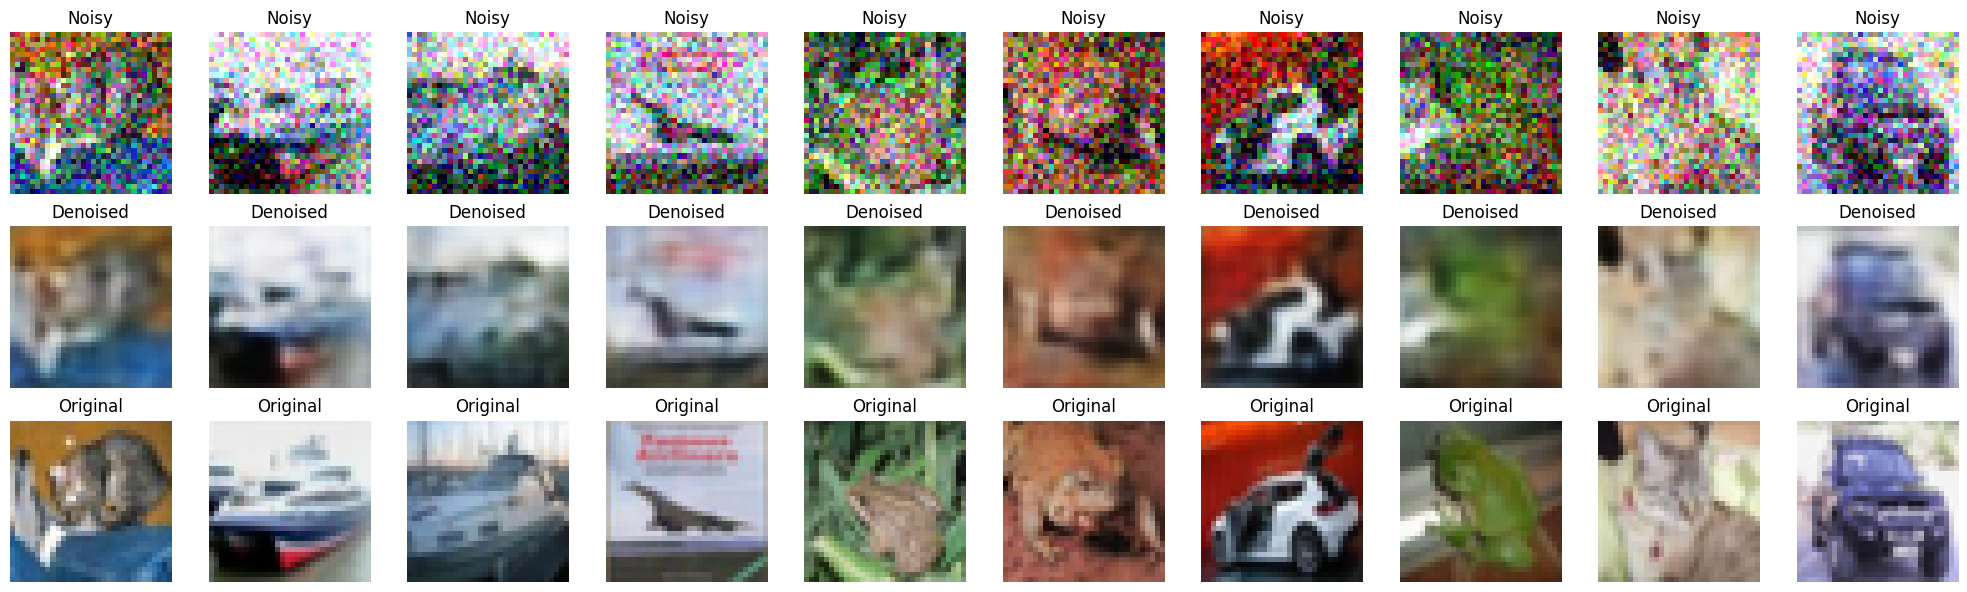

In [ ]:
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

noise_factor = 0.2
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

def build_autoencoder():
    input_img = layers.Input(shape=(32, 32, 3))

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(input_img, decoded)
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

autoencoder.fit(x_train_noisy, x_train,
                epochs=20,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test_noisy, x_test))

decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i])
    plt.title("Noisy")
    plt.axis("off")

    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Denoised")
    plt.axis("off")

    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_test[i])
    plt.title("Original")
    plt.axis("off")

plt.tight_layout()
plt.show()


# Problem - 4 : Training a CNN based CIFAR-10 classifier without any single-image data augmentation techniques

Epoch 1/15
782/782 - 28s - 36ms/step - accuracy: 0.4683 - loss: 1.4653 - val_accuracy: 0.5873 - val_loss: 1.1562
Epoch 2/15
782/782 - 25s - 31ms/step - accuracy: 0.6431 - loss: 1.0141 - val_accuracy: 0.6491 - val_loss: 1.0117
Epoch 3/15
782/782 - 24s - 31ms/step - accuracy: 0.7109 - loss: 0.8319 - val_accuracy: 0.7072 - val_loss: 0.8409
Epoch 4/15
782/782 - 25s - 32ms/step - accuracy: 0.7489 - loss: 0.7226 - val_accuracy: 0.7218 - val_loss: 0.8126
Epoch 5/15
782/782 - 25s - 32ms/step - accuracy: 0.7797 - loss: 0.6348 - val_accuracy: 0.7156 - val_loss: 0.8277
Epoch 6/15
782/782 - 25s - 32ms/step - accuracy: 0.8071 - loss: 0.5589 - val_accuracy: 0.7455 - val_loss: 0.7527
Epoch 7/15
782/782 - 24s - 31ms/step - accuracy: 0.8289 - loss: 0.4906 - val_accuracy: 0.7474 - val_loss: 0.7811
Epoch 8/15
782/782 - 26s - 33ms/step - accuracy: 0.8495 - loss: 0.4283 - val_accuracy: 0.7352 - val_loss: 0.8242
Epoch 9/15
782/782 - 24s - 30ms/step - accuracy: 0.8711 - loss: 0.3647 - val_accuracy: 0.7454 - 

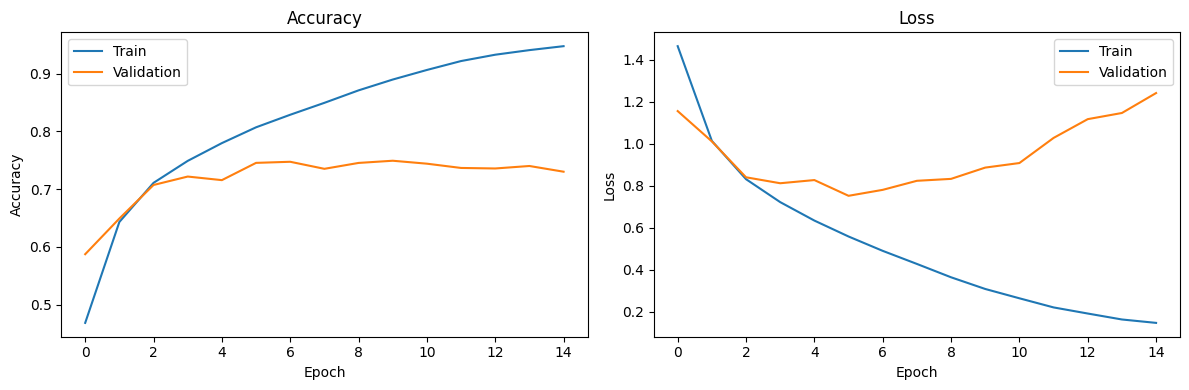

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

def build_cnn():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_cnn()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=15, batch_size=64,
                    validation_data=(x_test, y_test), verbose=2)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc:.2%}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Train")
plt.plot(history.history['val_accuracy'], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Train")
plt.plot(history.history['val_loss'], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


# Problem - 5 : Training a CNN based CIFAR-10 classifier with a single/multiple single-image data augmentation techniques

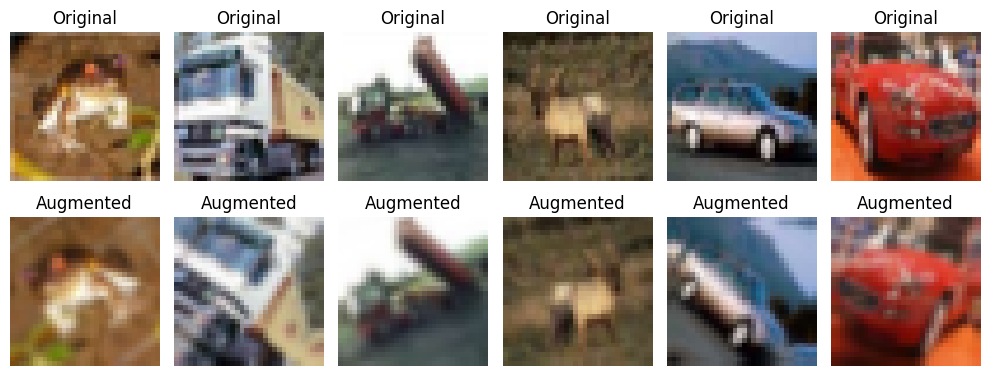

Epoch 1/15
782/782 - 27s - 35ms/step - accuracy: 0.4104 - loss: 1.6194 - val_accuracy: 0.5434 - val_loss: 1.2848
Epoch 2/15
782/782 - 28s - 35ms/step - accuracy: 0.5370 - loss: 1.2967 - val_accuracy: 0.5604 - val_loss: 1.2493
Epoch 3/15
782/782 - 26s - 33ms/step - accuracy: 0.5861 - loss: 1.1653 - val_accuracy: 0.6107 - val_loss: 1.1109
Epoch 4/15
782/782 - 27s - 34ms/step - accuracy: 0.6222 - loss: 1.0689 - val_accuracy: 0.6429 - val_loss: 1.0504
Epoch 5/15
782/782 - 27s - 35ms/step - accuracy: 0.6484 - loss: 1.0020 - val_accuracy: 0.6753 - val_loss: 0.9377
Epoch 6/15
782/782 - 28s - 35ms/step - accuracy: 0.6617 - loss: 0.9574 - val_accuracy: 0.6579 - val_loss: 0.9918
Epoch 7/15
782/782 - 28s - 36ms/step - accuracy: 0.6765 - loss: 0.9175 - val_accuracy: 0.7028 - val_loss: 0.8559
Epoch 8/15
782/782 - 27s - 34ms/step - accuracy: 0.6872 - loss: 0.8896 - val_accuracy: 0.7125 - val_loss: 0.8240
Epoch 9/15
782/782 - 28s - 35ms/step - accuracy: 0.7021 - loss: 0.8518 - val_accuracy: 0.7080 - 

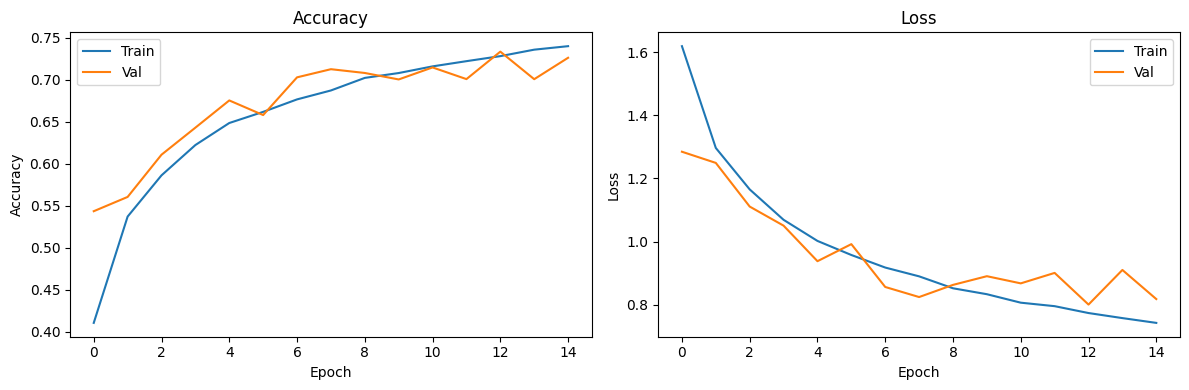

In [4]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

plt.figure(figsize=(10, 4))
for i in range(6):
    augmented_img = data_augmentation(tf.expand_dims(x_train[i], 0))
    plt.subplot(2, 6, i+1)
    plt.imshow(x_train[i])
    plt.title("Original")
    plt.axis("off")
    
    plt.subplot(2, 6, i+7)
    plt.imshow(augmented_img[0].numpy())
    plt.title("Augmented")
    plt.axis("off")
plt.tight_layout()
plt.show()

def build_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        data_augmentation,
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

model = build_model()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=15, batch_size=64,
                    validation_data=(x_test, y_test), verbose=2)

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest accuracy: {test_acc:.2%}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
